# Titanic: análisis exploratorio y factores asociados a la supervivencia

## Objetivo

Analizar qué variables demográficas, socioeconómicas y familiares parecen estar asociadas a la supervivencia de los pasajeros del Titanic.

## Preguntas guía
- ¿Qué tan alta fue la tasa general de supervivencia?
- ¿Influyeron el sexo y la clase del pasajero?
- ¿La edad y el tamaño de la familia muestran patrones relevantes?
- ¿Qué conclusiones de negocio o interpretación pueden extraerse del análisis?

## Preparación de datos

Se imputan valores faltantes, se construyen variables derivadas de edad y tamaño de familia, y se prepara una tabla analítica para el resto de las visualizaciones.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
con = duckdb.connect()

df = pd.read_csv("../data/raw/titanic.csv")

df_clean = df.copy()
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

df_model = df_clean.drop(columns=["Cabin"]).copy()

df_model["grupo_edad"] = pd.cut(
    df_model["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Niño", "Adolescente", "Joven Adulto", "Adulto", "Adulto Mayor"]
)

df_model["tamano_familia"] = df_model["SibSp"] + df_model["Parch"] + 1

df_model.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,grupo_edad,tamano_familia
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Joven Adulto,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adulto,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Joven Adulto,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Joven Adulto,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Joven Adulto,1


## Supervivencia general

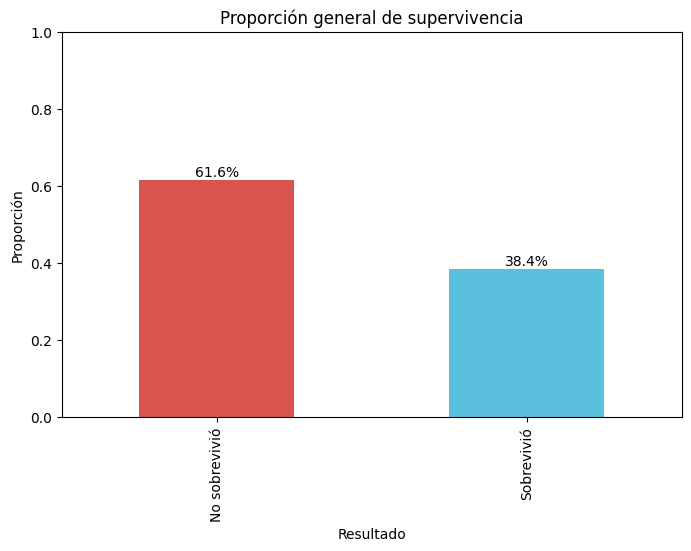

In [11]:
supervivencia = df_model["Survived"].value_counts(normalize=True).sort_index()
supervivencia.index = ["No sobrevivió", "Sobrevivió"]

supervivencia.plot(kind="bar", figsize=(8,5), color=["#d9534f", "#5bc0de"])
plt.title("Proporción general de supervivencia")
plt.xlabel("Resultado")
plt.ylabel("Proporción")
for i, v in enumerate(supervivencia):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.ylim(0, 1)
plt.show()

## Insight

Los datos muestran que la proporción general de supervivencia fue menor al 50 %, por lo que la mayoría de los pasajeros no sobrevivió.

Esto sugiere un desenlace ampliamente adverso y refuerza la conveniencia de analizar variables como sexo, clase y edad para entender qué factores podrían estar asociados a diferencias en el resultado.

## Supervivencia por sexo

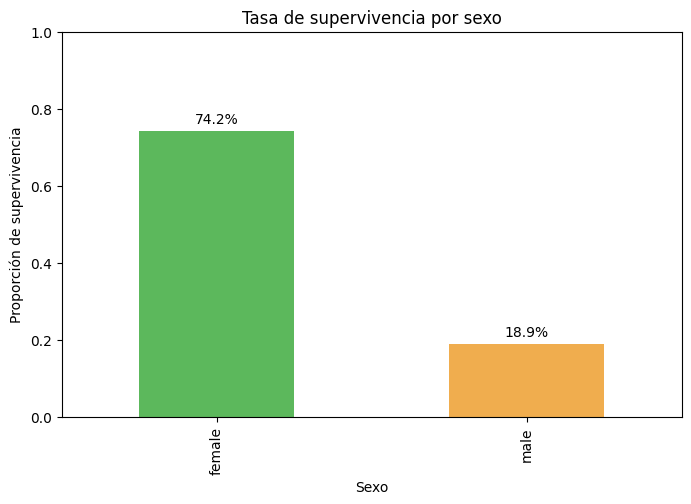

In [12]:
df_model.groupby("Sex")["Survived"].mean().plot(kind="bar", figsize=(8,5), color=["#5cb85c", "#f0ad4e"])
plt.title("Tasa de supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Proporción de supervivencia")
plt.ylim(0, 1)
for i, v in enumerate(df_model.groupby("Sex")["Survived"].mean()):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center")
plt.show()

## Insight

Los datos muestran que las mujeres registran una tasa de supervivencia considerablemente superior a la de los hombres.

Esto sugiere que el sexo podría estar asociado de forma relevante con la probabilidad de supervivencia y que esta variable puede aportar valor explicativo en análisis posteriores.

## Supervivencia por clase

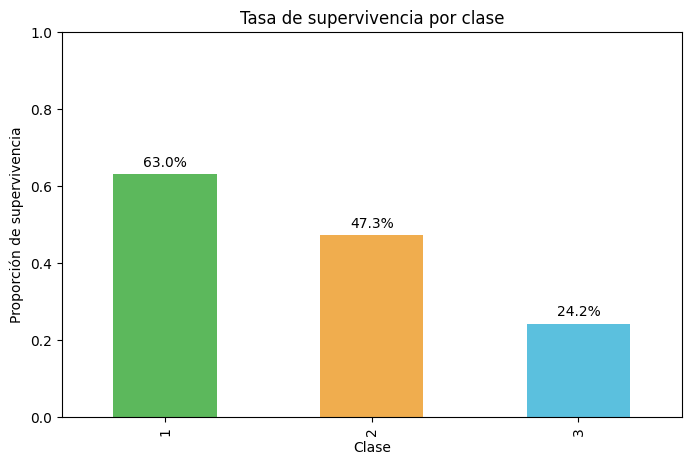

In [13]:
df_model.groupby("Pclass")["Survived"].mean().plot(
    kind="bar", figsize=(8, 5), color=["#5cb85c", "#f0ad4e", "#5bc0de"]
)
plt.title("Tasa de supervivencia por clase")
plt.xlabel("Clase")
plt.ylabel("Proporción de supervivencia")
plt.ylim(0, 1)

for i, v in enumerate(df_model.groupby("Pclass")["Survived"].mean()):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center")

plt.show()

## Insight

Los datos muestran que los pasajeros de primera clase registran la mayor tasa de supervivencia, seguidos por los de segunda clase, mientras que la tercera clase presenta la más baja.

Esto sugiere que la clase del pasajero podría estar asociada de manera importante con el resultado, por lo que `Pclass` aparece como una variable relevante para explicar diferencias en la supervivencia.

## Supervivencia por sexo + clase

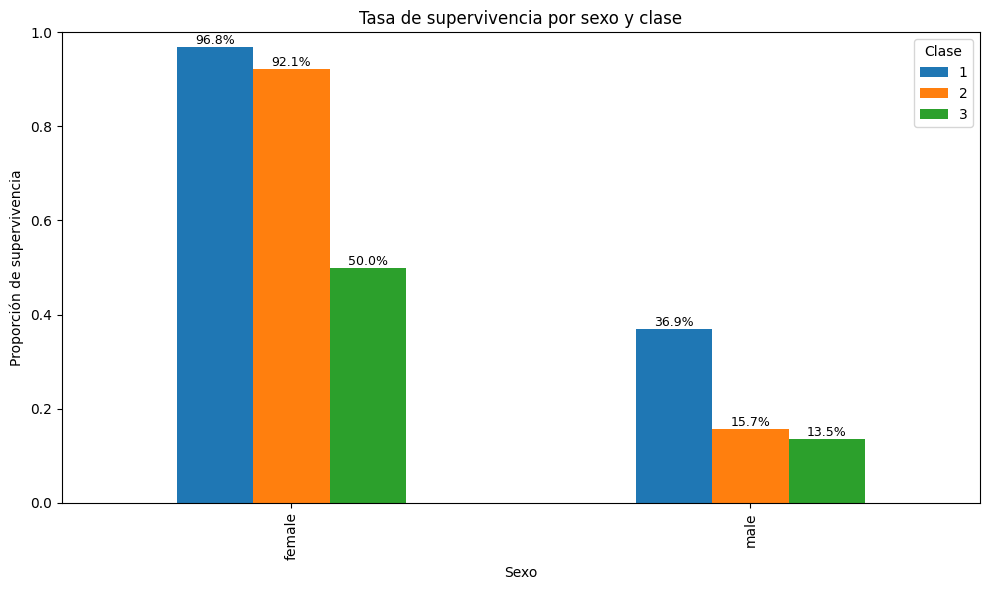

In [14]:
ax = (
    df_model.groupby(["Sex", "Pclass"])["Survived"]
    .mean()
    .unstack()
    .plot(kind="bar", figsize=(10, 6))
)
ax.set_title("Tasa de supervivencia por sexo y clase")
ax.set_xlabel("Sexo")
ax.set_ylabel("Proporción de supervivencia")
ax.set_ylim(0, 1)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.legend(title="Clase")
plt.tight_layout()
plt.show()

## Insight

Los datos muestran que las mujeres presentan tasas de supervivencia superiores a las de los hombres en todas las clases, y que la clase modula con claridad este patrón.

Esto sugiere que la combinación entre `Sex` y `Pclass` podría estar asociada de forma especialmente fuerte con la supervivencia. En esta lectura, las mujeres de primera clase concentran los resultados más favorables, mientras que los hombres de tercera clase muestran los más desfavorables.

## Supervivencia por grupo etario

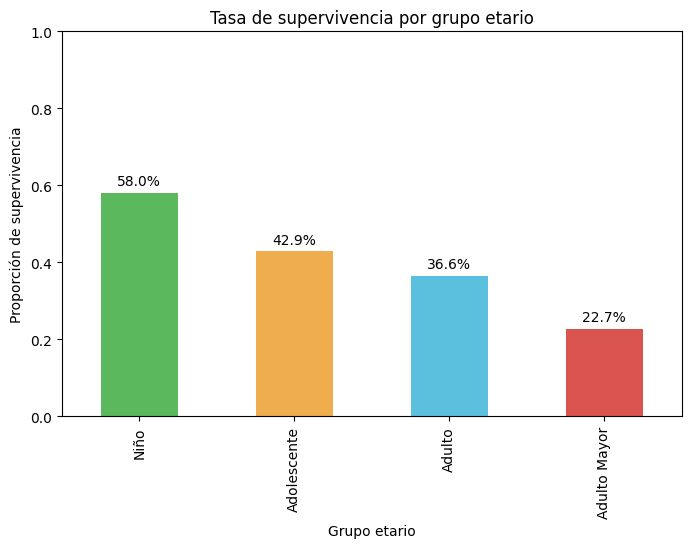

In [15]:
df_model["grupo_edad_simple"] = pd.cut(
    df_model["Age"],
    bins=[0, 12, 18, 60, 100],
    labels=["Niño", "Adolescente", "Adulto", "Adulto Mayor"]
)

survival_by_age = df_model.groupby("grupo_edad_simple", observed=False)["Survived"].mean()

survival_by_age.plot(kind="bar", figsize=(8,5), color=["#5cb85c", "#f0ad4e", "#5bc0de", "#d9534f"])
plt.title("Tasa de supervivencia por grupo etario")
plt.xlabel("Grupo etario")
plt.ylabel("Proporción de supervivencia")
plt.ylim(0, 1)
for i, v in enumerate(survival_by_age):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center")
plt.show()

## Insight

Los datos muestran que los niños presentan la mayor tasa de supervivencia entre los grupos etarios observados, mientras que los adultos mayores registran los valores más bajos. Los adultos se ubican en un nivel intermedio.

Esto sugiere que la edad podría estar asociada a diferencias relevantes en la probabilidad de supervivencia y que `Age`, o variables derivadas como `grupo_edad`, podrían aportar valor explicativo en un modelo posterior.

## Supervivencia por tamaño de familia

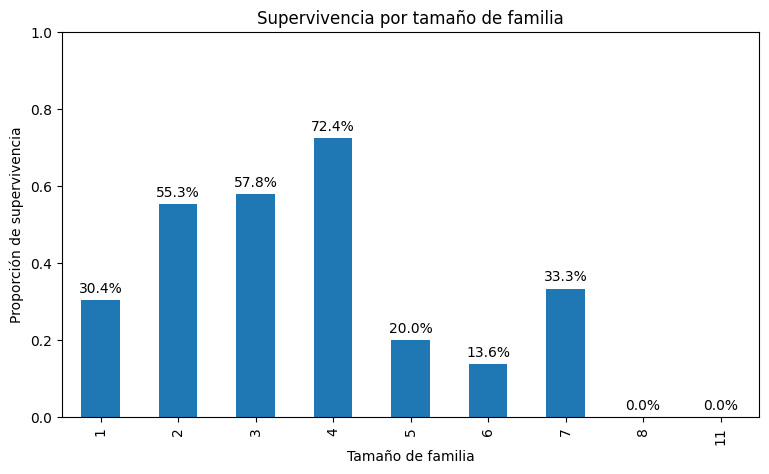

In [16]:
survival_by_family = df_model.groupby("tamano_familia")["Survived"].mean()

survival_by_family.plot(kind="bar", figsize=(9,5))
plt.title("Supervivencia por tamaño de familia")
plt.xlabel("Tamaño de familia")
plt.ylabel("Proporción de supervivencia")
plt.ylim(0, 1)

for i, v in enumerate(survival_by_family):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center")

plt.show()

## Insight

Los datos muestran un patrón no lineal entre el tamaño de la familia y la supervivencia: los grupos pequeños o medianos registran mejores tasas que quienes viajaban solos o en familias muy grandes.

Esto sugiere que el tamaño del núcleo familiar podría estar asociado al resultado final. Una posible explicación es que ciertos tamaños de grupo hayan facilitado o dificultado la capacidad de respuesta durante la evacuación, aunque los datos no permiten afirmarlo como causa probada.

En términos analíticos, `tamano_familia` parece ser una variable útil para complementar la lectura demográfica y socioeconómica de la supervivencia.

## Distribución de edad por resultado

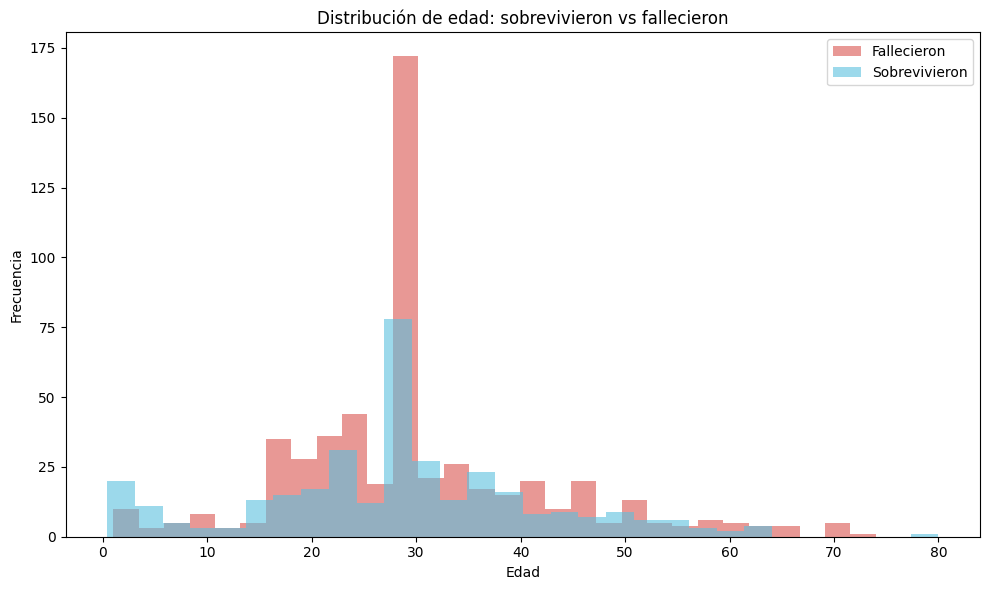

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_model[df_model["Survived"] == 0]["Age"],
    bins=30,
    alpha=0.6,
    label="Fallecieron",
    color="#d9534f",
)

plt.hist(
    df_model[df_model["Survived"] == 1]["Age"],
    bins=30,
    alpha=0.6,
    label="Sobrevivieron",
    color="#5bc0de",
)

plt.title("Distribución de edad: sobrevivieron vs fallecieron")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

## Insight

Los datos muestran que la distribución de edades difiere entre quienes sobrevivieron y quienes no sobrevivieron. En particular, los pasajeros de menor edad parecen tener una presencia relativamente mayor entre los sobrevivientes, mientras que en edades más altas la frecuencia se concentra más en quienes no sobrevivieron.

Esto sugiere que la edad podría estar asociada al resultado final, aunque el gráfico por sí solo no prueba una relación causal. Una posible explicación es que la vulnerabilidad o las condiciones de evacuación hayan afectado de forma distinta a los grupos etarios.

En términos analíticos, esta visualización refuerza que `Age` no solo aporta valor como variable individual, sino también como dimensión útil para segmentar el riesgo y complementar la lectura de supervivencia por grupo etario.

In [18]:
# Pega esta celda al final de tu notebook.
# Ajusta los valores de métricas y textos según tu análisis.
# El archivo generado será consumido por generar_reporte_desde_notebook.py

from pathlib import Path
import json

Path("../outputs").mkdir(exist_ok=True)

report_payload = {
    "report": {
        "title": "Titanic: reporte ejecutivo automatizado",
        "subtitle": "Análisis de datos con Python + IA aplicada",
        "objective": "Identificar qué variables estuvieron más asociadas a la supervivencia y generar un entregable ejecutivo automático desde el notebook.",
        "executive_summary": (
            "La tasa general de supervivencia fue 38,4%, por lo que la mayoría de los pasajeros no sobrevivió. "
            "El sexo y la clase del pasajero aparecen como los factores más asociados a la supervivencia: "
            "las mujeres alcanzaron 74,2% frente a 18,9% en hombres, y la primera clase superó ampliamente a la tercera. "
            "La edad y el tamaño de la familia también aportan capacidad explicativa: los niños mostraron mejores resultados que los adultos mayores, "
            "y los grupos familiares pequeños o medianos superaron a quienes viajaban solos o en familias muy grandes."
        ),
        "key_findings": [
            "Sexo: mujeres 74,2% vs hombres 18,9%.",
            "Clase: 1ra clase 63,0% vs 3ra clase 24,2%.",
            "Combinación crítica: mujeres de 1ra clase 96,8%; hombres de 3ra clase 13,5%.",
            "Edad: niños 58,0%; adultos mayores 22,7%.",
            "Tamaño de familia: solo 30,4%; familia de 4: 72,4%."
        ],
        "executive_findings": [
            "Sexo y clase son las variables más asociadas a la supervivencia.",
            "Edad y tamaño de familia mejoran la explicación del fenómeno.",
            "Este flujo puede automatizar métricas, gráficos y entregables ejecutivos desde Python."
        ],
        "recommendations": [
            "Usar Sex, Pclass, Age y tamano_familia como variables base en un modelo predictivo.",
            "Mantener un pipeline reproducible que genere métricas, gráficos y entregables ejecutivos desde Python.",
            "Agregar una app Streamlit para consumo interactivo de usuarios no técnicos."
        ],
        "next_step_note": "Siguiente paso sugerido: Streamlit + modelo predictivo."
    },
    "metrics": {
        "tasa_supervivencia_general": 0.383838,
        "supervivencia_mujeres": 0.742038,
        "supervivencia_hombres": 0.188908,
        "supervivencia_1ra": 0.629630,
        "supervivencia_2da": 0.472826,
        "supervivencia_3ra": 0.242363,
        "mujer_1ra": 0.968085,
        "mujer_2da": 0.921053,
        "mujer_3ra": 0.500000,
        "hombre_1ra": 0.368852,
        "hombre_2da": 0.157407,
        "hombre_3ra": 0.135447,
        "ninos": 0.579710,
        "adolescentes": 0.428571,
        "adultos": 0.400000,
        "adultos_mayores": 0.227273,
        "familia_1": 0.303538,
        "familia_2": 0.552795,
        "familia_3": 0.578431,
        "familia_4": 0.724138
    }
}

payload_path = Path("../outputs/report_payload_titanic.json")
with open(payload_path, "w", encoding="utf-8") as f:
    json.dump(report_payload, f, ensure_ascii=False, indent=2)

print(f"Payload exportado en: {payload_path}")

Payload exportado en: ../outputs/report_payload_titanic.json


## Hallazgos ejecutivos

1. Los datos muestran que la mayoría de los pasajeros no sobrevivió, lo que sugiere un evento con desenlace ampliamente adverso.
2. El sexo aparece como una de las variables más asociadas a la supervivencia, con mejores resultados observados en mujeres que en hombres.
3. La clase del pasajero también muestra una asociación clara con el resultado, con patrones más favorables en primera clase y menos favorables en tercera.
4. La combinación entre sexo y clase permite distinguir perfiles con comportamientos de supervivencia claramente diferentes.
5. La edad parece aportar capacidad explicativa adicional, ya que los grupos más jóvenes muestran mejores resultados relativos que los de mayor edad.
6. El tamaño de la familia presenta un patrón no lineal, por lo que podría ser una variable complementaria relevante en análisis posteriores.

## Conclusión

Los datos muestran que la supervivencia en el Titanic no se distribuyó de manera homogénea entre los pasajeros.

Esto sugiere que variables demográficas y socioeconómicas como sexo, clase, edad y tamaño de familia podrían estar asociadas a diferencias relevantes en el resultado final.

En conjunto, el análisis permite construir una narrativa clara para portafolio y ofrece una base consistente para un modelo predictivo posterior.